<table style="width:100%; font-size:11pt; border-collapse:collapse">
    <tr>
        <td colspan="2"
            style="border: 1px #0098cd solid;
                   background-color:#E6F4F9;
                   color:#0098CD;
                   text-align:center;
                   font-weight:bold;
                   padding:8px;">
            Universidad de Oriente
        </td>
    </tr>
    <tr>
        <td style="border: 1px #0098cd solid;
                   background-color:#E6F4F9;
                   color:#0098CD;
                   width:50%;
                   text-align:center;
                   padding:6px;">
                            Machine Learning
        </td>
        <td style="border: 1px #0098cd solid;
                   background-color:#E6F4F9;
                   color:#0098CD;
                   width:50%;
                   text-align:center;
                   padding:6px;">
            Práctica 4: Regresión lineal simple pt 2
        </td>
    </tr>
    <tr>


</table>


## Ejercicio 1


# Predicción de Precios de Vehículos Toyota Usados

Se dispone de un conjunto de datos extraído de listados de venta de vehículos Toyota de segunda mano.

Se desea analizar la relación entre el uso que ha tenido el vehículo y su valor en el mercado.

Para este análisis, nos enfocaremos en dos variables principales:

# $X$: representa el millas del vehículo .

# $Y$: representa el precio de venta

Con base en esta información, se pide:

* Realizar un gráfico de dispersión que permita visualizar la relación entre el kilometraje y el precio del vehículo.

* Ajustar un modelo de regresión lineal simple de la forma  $Y = \beta_0 + \beta_1 X$ donde $X$ representa el  kilometraje e $Y$ representa el precio.

* Determinar la ecuación estimada del modelo y representar la ecuación de la recta sobre el gráfico de datos.

* Estimar: El precio esperado para un Toyota que tiene 50,000 ml y otro con 200,000 ml

* Calcular e interpretar:El error cuadrático medio (MSE).

* La raíz del error cuadrático medio (RMSE).

* El coeficiente de determinación ($R^2$).

In [1]:
import numpy as np

import pandas as pd
import matplotlib.pyplot as plt
import sklearn

In [2]:
df = pd.read_csv('toyota.csv')

In [3]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,GT86,2016,16000,Manual,24089,Petrol,265,36.2,2.0
1,GT86,2017,15995,Manual,18615,Petrol,145,36.2,2.0
2,GT86,2015,13998,Manual,27469,Petrol,265,36.2,2.0
3,GT86,2017,18998,Manual,14736,Petrol,150,36.2,2.0
4,GT86,2017,17498,Manual,36284,Petrol,145,36.2,2.0


In [22]:
#  variable Y
resultados_precio = df['price'].values

# variable X
# Le agregamos .values.reshape(-1, 1) directamente para que scikit-learn lo acepte como matriz
#millage = df['mileage'].values.reshape(-1, 1)
millage = df['year'].values.reshape(-1, 1) #cambiando valores de x

print("Datos cargados correctamente.")
print(f"Total de vehículos en el dataset: {len(resultados_precio)}")

Datos cargados correctamente.
Total de vehículos en el dataset: 6738


a) Para visualizar la relación entre las variables millage y el precio del vehiculo, se construye un gráfico de dispersión. Este tipo de gráfico permite representar cada observación como un punto en el plano cartesiano, donde el eje horizontal corresponde al millage y el eje vertical al precio.

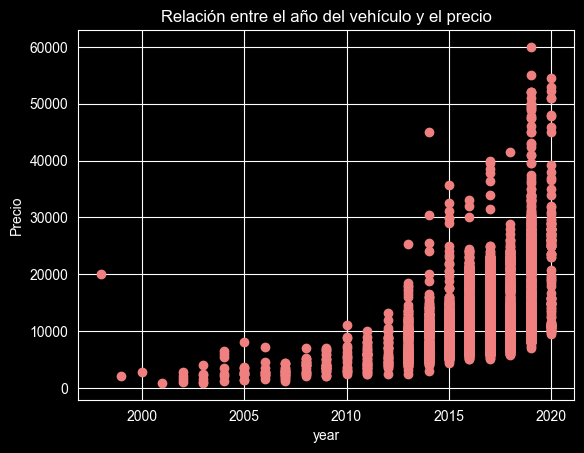

In [21]:
plt.figure()
plt.scatter(millage, resultados_precio ,color="lightcoral")
#plt.xlabel("Millage")
plt.xlabel("year")
plt.ylabel("Precio")
plt.title("Relación entre el año del vehículo y el precio") #practica 4
plt.show()

*El gráfico muestra una tendencia negativa clara entre las variables. A medida que aumenta el millage, los resultados del precio tienden a ser precio. Los puntos se distribuyen de manera decendentes de izquierda a derecha, lo que sugiere una relación lineal negativa entre ambas variables.*

 b) Se ajusta un modelo de regresión lineal simple para analizar la relación entre las horas de estudio y el resultado obtenido en el examen. El modelo considerado es de la forma

**$$ Y = \beta_0 + \beta_1 X$$**

In [6]:
# Importamos la clase de Regresión Lineal de scikit-learn
from sklearn.linear_model import LinearRegression

regresion_lineal = LinearRegression() # creamos una instancia de LinearRegression

#Instruimos a la regresión lineal que aprenda de los datos (x, y)
regresion_lineal.fit(millage.reshape(-1, 1), resultados_precio)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [7]:
#Se muestran los parámetros del modelo
intercepto = regresion_lineal.intercept_
coeficiente = regresion_lineal.coef_

print("El valor del intercepto (punto de partida) es %s" %intercepto)
print("El valor del coeficiente (como decrementa) es %s" %coeficiente)

El valor del intercepto (punto de partida) es 14781.674203311417
El valor del coeficiente (como decrementa) es [-0.09884247]


c) Cononcienodo los parámetros se tiene que la recta de regresión es de la forma:

In [8]:
print("La recta de regresión es y = %5.5f+%5.5f x" %(intercepto, coeficiente[0]))

La recta de regresión es y = 14781.67420+-0.09884 x


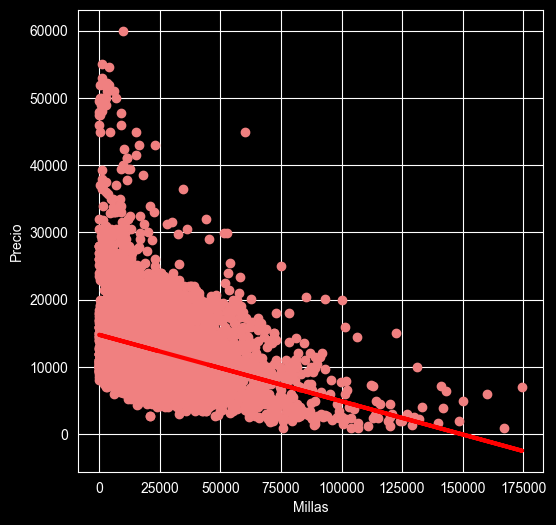

In [9]:
# Representar x e y
fig = plt.figure(figsize=(6,6))
plt.scatter(millage, resultados_precio, color = "lightcoral")

x = millage.reshape(-1,1)

# Representar la recta de regresión
y_pred = regresion_lineal.predict(x) #Predecir los valores de x
plt.plot(x, y_pred, color='red', linewidth=3)

# Definir ejes
plt.xlabel("Millas")
plt.ylabel("Precio")

# Mostrar gráfico
plt.show()

d) Para estimar el resultado esperado se utiliza la ecuación del modelo de regresión lineal ajustado. Sustituyendo los valores de 50000 y 200000 millas en el modelo, se obtienen las predicciones del resultado esperado en el examen para esos niveles de estudio.

In [10]:
#Predecir para 50000 horas
milla_1 = np.array([50000])
resultado_1 = regresion_lineal.predict(milla_1.reshape(-1,1))

print("El resultado esperado al estudiar 50000 milla %s" %resultado_1[0])

El resultado esperado al estudiar 50000 milla 9839.550948429121


In [11]:
#Predecir para 200000 horas
milla_2 = np.array([200000])
resultado_2 = regresion_lineal.predict(milla_2.reshape(-1,1))

print("El resultado esperado al estudiar 1000000 milla %s" %resultado_2[0])

El resultado esperado al estudiar 1000000 milla -4986.818816217761


e) Para evaluar el desempeño del modelo de regresión lineal simple se calculan tres métricas comunes: el error cuadrático medio (MSE), el RMSE y el coeficiente de determinación.

El error cuadrático medio mide el promedio de los cuadrados de las diferencias entre los valores observados y los valores predichos por el modelo. Un valor pequeño de MSE indica que el modelo realiza predicciones cercanas a los valores reales.

El RMSE es la raíz cuadrada del MSE y se interpreta en las mismas unidades que la variable respuesta. Esta métrica indica, en promedio, cuánto se desvían las predicciones del modelo respecto a los valores reales.

In [12]:
# importamos el cálculo del error cuadrático medio (MSE)
from sklearn.metrics import mean_squared_error

# Predecimos los valores y para los datos usados en el entrenamiento
prediccion_entrenamiento = regresion_lineal.predict(millage.reshape(-1,1))

# Calculamos el Error Cuadrático Medio (MSE = Mean Squared Error)
mse = mean_squared_error(y_true = millage, y_pred = prediccion_entrenamiento)

# La raíz cuadrada del MSE es el RMSE
rmse = np.sqrt(mse)
print('Error Cuadrático Medio (MSE) = ' + str(mse))
print('Raíz del Error Cuadrático Medio (RMSE) = ' + str(rmse))

Error Cuadrático Medio (MSE) = 548414031.7898996
Raíz del Error Cuadrático Medio (RMSE) = 23418.241432479503


El coeficiente de determinación mide la proporción de la variabilidad de la variable respuesta que es explicada por el modelo de regresión. Su valor se encuentra entre 0 y 1. Un valor cercano a 1 indica que el modelo explica una gran parte de la variabilidad de los datos, mientras que un valor cercano a 0 indica una baja capacidad explicativa.

In [13]:
# calculamos el coeficiente de determinación R2
r2 = regresion_lineal.score(millage.reshape(-1,1), resultados_precio)
print("Coeficiente de Determinación R2 es %s" %r2)

Coeficiente de Determinación R2 es 0.08876575327921865
